<a href="https://colab.research.google.com/github/quants-blackbox/Time-Series-Textbooks/blob/main/copula_10_assets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -qq pyvinecopulib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.1 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt



In [3]:
tickers = [
        "AGL.JO", "AMS.JO", "ANG.JO", "ANH.JO", "BHP.JO",
        "BID.JO", "BTI.JO", "BVT.JO", "CFR.JO", "CLS.JO",
        "CPI.JO", "DSY.JO", "EXX.JO", "FSR.JO", "GFI.JO",
        "GLN.JO", "GRT.JO", "IMP.JO", "INL.JO", "INP.JO",
        "KIO.JO", "MNP.JO", "MRP.JO", "MTN.JO", "NED.JO",
        "NPN.JO", "NRP.JO", "OMU.JO", "PRX.JO", "REM.JO",
        "RNI.JO", "SBK.JO", "SHP.JO", "SLM.JO", "SOL.JO",
        "SSW.JO", "TBS.JO", "VOD.JO", "WHL.JO", "ABG.JO"
]

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = yf.download(tickers, start="2018-01-01", end="2024-01-01")["Close"]

/tmp/ipykernel_18571/1574210548.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2018-01-01", end="2024-01-01")["Close"]
[*********************100%***********************]  40 of 40 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BHP.JO', 'AMS.JO']: YFTzMissingError('possibly delisted; no timezone found')


In [6]:
data_cleaned = data.dropna(axis=1, how='all')
returns = np.log(data_cleaned / data_cleaned.shift(1)).dropna()

In [7]:
returns.head()

Ticker,ABG.JO,AGL.JO,ANG.JO,ANH.JO,BID.JO,BTI.JO,BVT.JO,CFR.JO,CLS.JO,CPI.JO,...,REM.JO,RNI.JO,SBK.JO,SHP.JO,SLM.JO,SOL.JO,SSW.JO,TBS.JO,VOD.JO,WHL.JO
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-20,0.008143,-0.017264,0.014537,-0.009099,0.009407,-0.014603,0.007244,0.007534,0.005825,0.004320,...,0.008716,0.016403,0.002669,0.007854,-0.004419,0.020646,-0.007654,0.000662,0.004386,0.005560
2023-04-21,-0.009621,-0.059921,-0.004892,-0.002905,0.002100,0.003900,-0.003093,0.000337,0.004135,-0.000385,...,-0.003332,-0.012564,0.001420,-0.006806,-0.013734,-0.042885,-0.018416,-0.000968,-0.002353,0.003229
2023-04-24,-0.001594,-0.011627,0.023286,0.019181,0.002777,0.013418,-0.000241,0.017377,0.016028,-0.013987,...,-0.001089,0.003824,-0.000769,-0.000592,-0.003598,-0.007063,-0.007857,0.015681,-0.001138,-0.006778
2023-04-25,-0.007432,-0.023182,0.002769,0.005460,0.011248,0.017186,-0.002578,0.009371,0.018424,-0.014324,...,0.004638,0.006569,0.001301,0.013800,-0.007417,-0.009860,-0.015901,-0.003822,-0.000651,0.004626
2023-04-26,0.009764,0.012255,0.012687,0.009149,-0.006346,0.017871,0.007234,-0.023974,-0.008794,0.019095,...,0.010215,0.010786,0.006656,-0.002474,0.014601,0.025640,-0.003261,-0.003735,0.003412,-0.000770


In [8]:
returns.to_csv('/content/drive/MyDrive/returns.csv', index=False)

In [9]:
from scipy.stats import rankdata

U = returns.copy()

for col in U.columns:
    U[col] = rankdata(U[col]) / (len(U)+1)

tau_matrix = U.corr(method="kendall")

In [10]:
tau_matrix

Ticker,ABG.JO,AGL.JO,ANG.JO,ANH.JO,BID.JO,BTI.JO,BVT.JO,CFR.JO,CLS.JO,CPI.JO,...,REM.JO,RNI.JO,SBK.JO,SHP.JO,SLM.JO,SOL.JO,SSW.JO,TBS.JO,VOD.JO,WHL.JO
Ticker,,,,,,,,,,,,,,,,,,,,,
ABG.JO,1.000000,0.287091,0.105043,0.101987,0.231015,0.051359,0.405488,0.101189,0.276194,0.469271,...,0.447346,0.257192,0.568002,0.362169,0.430954,0.315394,0.240715,0.207893,0.311618,0.354594
AGL.JO,0.287091,1.000000,0.161783,0.141187,0.101455,0.107036,0.200186,0.166966,0.139991,0.255465,...,0.134941,0.119394,0.231147,0.188227,0.255914,0.320311,0.316059,0.185968,0.180991,0.190751
ANG.JO,0.105043,0.161783,1.000000,0.067836,0.079662,-0.000332,0.080593,0.048701,0.046974,0.095210,...,0.117135,0.048701,0.072487,0.065444,0.076489,0.055611,0.322703,0.093216,0.054350,0.030496
ANH.JO,0.101987,0.141187,0.067836,1.000000,0.120191,0.390738,0.121919,0.236463,0.150488,0.121653,...,0.118597,0.205103,0.052688,0.071955,0.111045,0.021726,0.080991,0.198060,0.084914,0.084579
BID.JO,0.231015,0.101455,0.079662,0.120191,1.000000,0.120324,0.296127,0.146768,0.203774,0.180785,...,0.225566,0.185835,0.215467,0.273271,0.166069,0.148894,0.027174,0.156468,0.256603,0.184639
BTI.JO,0.051359,0.107036,-0.000332,0.390738,0.120324,1.000000,0.066241,0.100525,0.150887,0.126038,...,0.108365,0.188227,0.042456,0.045778,0.052299,0.005647,0.026377,0.099860,0.058204,0.072221
BVT.JO,0.405488,0.200186,0.080593,0.121919,0.296127,0.066241,1.000000,0.116869,0.333333,0.351538,...,0.346621,0.238057,0.407481,0.373862,0.392012,0.185968,0.158328,0.233406,0.351085,0.353266
CFR.JO,0.101189,0.166966,0.048701,0.236463,0.146768,0.100525,0.116869,1.000000,0.105043,0.108631,...,0.157132,0.147698,0.091223,0.129360,0.140816,-0.030363,0.044582,0.202312,0.056477,0.120723
CLS.JO,0.276194,0.139991,0.046974,0.150488,0.203774,0.150887,0.333333,0.105043,1.000000,0.319779,...,0.339047,0.235798,0.269152,0.416783,0.270800,0.146768,0.062787,0.279516,0.305505,0.277922


In [11]:
G = nx.Graph()

for i in range(tau_matrix.shape[0]):
    for j in range(i+1,tau_matrix.shape[0]):
        tau = abs(tau_matrix.iloc[i,j])
        G.add_edge(tickers[i], tickers[j], weight=tau)

In [12]:
T1 = nx.maximum_spanning_tree(G, algorithm="prim")

In [13]:
print(T1.edges(data=True))

[('AGL.JO', 'MTN.JO', {'weight': np.float64(0.5979004717294532)}), ('AGL.JO', 'GLN.JO', {'weight': np.float64(0.41394206032605674)}), ('AGL.JO', 'SLM.JO', {'weight': np.float64(0.31539432595840805)}), ('AMS.JO', 'INP.JO', {'weight': np.float64(0.46475317254667464)}), ('AMS.JO', 'GFI.JO', {'weight': np.float64(0.5509932894824264)}), ('AMS.JO', 'OMU.JO', {'weight': np.float64(0.2857617434057538)}), ('AMS.JO', 'KIO.JO', {'weight': np.float64(0.22157996146435452)}), ('ANG.JO', 'SOL.JO', {'weight': np.float64(0.32270281044448873)}), ('ANG.JO', 'FSR.JO', {'weight': np.float64(0.6557039399375457)}), ('ANH.JO', 'BVT.JO', {'weight': np.float64(0.23646269350873694)}), ('ANH.JO', 'BID.JO', {'weight': np.float64(0.3907381569330941)}), ('BHP.JO', 'BTI.JO', {'weight': np.float64(0.2961265032223772)}), ('BTI.JO', 'NRP.JO', {'weight': np.float64(0.41965710562835906)}), ('BVT.JO', 'OMU.JO', {'weight': np.float64(0.27871902199189424)}), ('CFR.JO', 'SBK.JO', {'weight': np.float64(0.41678293801076344)}), 

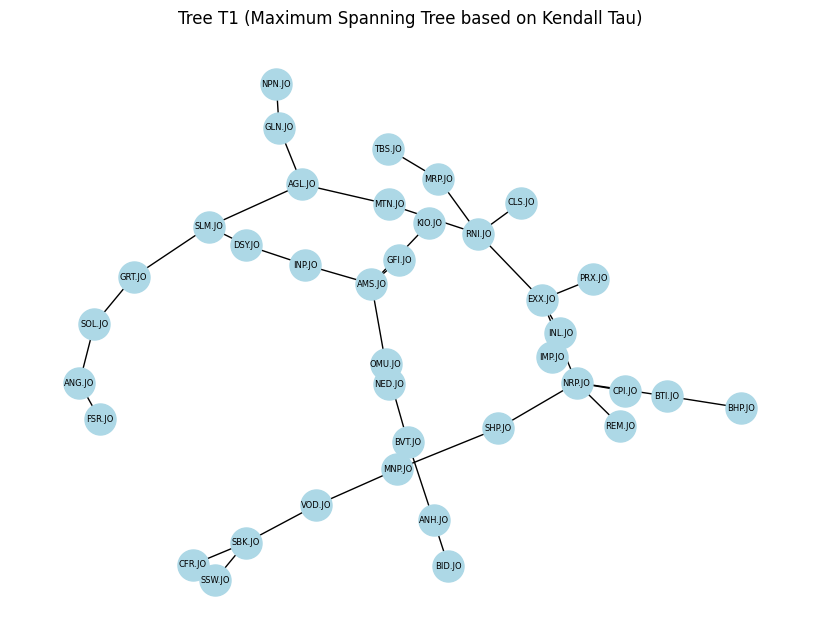

In [14]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(8,6))

pos = nx.spring_layout(T1)

nx.draw(
    T1,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=500,
    font_size=6
)

plt.title("Tree T1 (Maximum Spanning Tree based on Kendall Tau)")

plt.show()

In [15]:
import pyvinecopulib as pv
vine = pv.Vinecop.from_data(data=U.values)
U.values

array([[0.69714286, 0.20571429, 0.75428571, ..., 0.50285714, 0.66285714,
        0.64571429],
       [0.22285714, 0.01714286, 0.44571429, ..., 0.45142857, 0.44      ,
        0.57714286],
       [0.46285714, 0.32571429, 0.85142857, ..., 0.86857143, 0.46857143,
        0.29714286],
       ...,
       [0.91428571, 0.96      , 0.90285714, ..., 0.69142857, 0.97142857,
        0.92571429],
       [0.60571429, 0.42285714, 0.23428571, ..., 0.23428571, 0.22285714,
        0.38857143],
       [0.68      , 0.62857143, 0.44      , ..., 0.29714286, 0.38285714,
        0.69714286]])

In [16]:
print(vine)

<pyvinecopulib.Vinecop> Vinecop model with 38 variables
tree edge conditioned variables                                                                                                                conditioning variables var_types       family rotation       parameters   df   tau 
   1    1                 14, 3                                                                                                                                            c, c       Gumbel        0             2.80  1.0  0.64 
   1    2                 3, 35                                                                                                                                            c, c       Gumbel        0             1.50  1.0  0.33 
   1    3                35, 17                                                                                                                                            c, c      Student        0       0.70, 3.26  2.0  0.49 
   1    4                17, 34     

In [17]:
for edge in vine.pair_copulas[0]:
  print(edge.tau)

0.6428687540858695
0.3345640355108804
0.4895904434291295
0.33102269859973665
0.5096176176176176
0.8132948515893965
0.3947236023503237
0.24429299221301495
0.27541042857205444
0.2940315863828137
0.36488400822418116
0.22177413467410068
0.4601399429351771
0.4155173199978135
0.36084401676318306
0.287520253499988
0.4837147974831353
0.4187549016162487
0.8330687137319717
0.6012335916982949
0.5126330091434165
0.2799270524225476
0.42198516575426803
0.38839333744990673
0.35566589643380425
0.5898765459872547
0.6228225446021448
0.3994825221035984
0.3229384818967092
0.4853435905073527
0.4941569973712202
0.5607592357336597
0.3515940028190445
0.4075658786719104
0.2895667561390563
0.4702443359377691
0.4244019471828564


In [18]:
tickers = list(U.columns)
structure = vine.structure.matrix

threshold = 0.15

for tree in range(vine.dim - 1):

    print("\nTree", tree+1)

    for edge in range(vine.dim - tree - 1):

        cop = vine.get_pair_copula(tree, edge)

        tau = cop.tau

        if abs(tau) > threshold:

            i = structure[tree][edge]
            j = structure[tree+1][edge]

            print(f"{tickers[i-1]} - {tickers[j-1]}  tau={tau}")


Tree 1
ANG.JO - SSW.JO  tau=0.6428687540858695
SSW.JO - IMP.JO  tau=0.3345640355108804
IMP.JO - SOL.JO  tau=0.4895904434291295
SOL.JO - EXX.JO  tau=0.33102269859973665
AGL.JO - PRX.JO  tau=0.5096176176176176
PRX.JO - CFR.JO  tau=0.8132948515893965
ANH.JO - CFR.JO  tau=0.3947236023503237
CFR.JO - PRX.JO  tau=0.24429299221301495
PRX.JO - AGL.JO  tau=0.27541042857205444
AGL.JO - MNP.JO  tau=0.2940315863828137
GRT.JO - ABG.JO  tau=0.36488400822418116
AGL.JO - KIO.JO  tau=0.22177413467410068
KIO.JO - EXX.JO  tau=0.4601399429351771
EXX.JO - SOL.JO  tau=0.4155173199978135
SOL.JO - ABG.JO  tau=0.36084401676318306
ABG.JO - NED.JO  tau=0.287520253499988
SBK.JO - NED.JO  tau=0.4837147974831353
ABG.JO - NED.JO  tau=0.4187549016162487
INP.JO - FSR.JO  tau=0.8330687137319717
NED.JO - SBK.JO  tau=0.6012335916982949
OMU.JO - BVT.JO  tau=0.5126330091434165
BVT.JO - OMU.JO  tau=0.2799270524225476
OMU.JO - FSR.JO  tau=0.42198516575426803
MTN.JO - SBK.JO  tau=0.38839333744990673
SBK.JO - NED.JO  tau=0.35

In [19]:
d = vine.dim
tau_matrix = np.zeros((d, d))

structure = vine.structure.matrix

for tree in range(d - 1):
    for edge in range(d - 1 - tree):

        # convert to python index
        i = structure[tree, edge] - 1
        j = structure[tree + 1, edge] - 1

        tau = vine.pair_copulas[tree][edge].tau

        tau_matrix[i, j] = tau
        tau_matrix[j, i] = tau

tau_df = pd.DataFrame(tau_matrix, index=tickers, columns=tickers)

print(tau_df)

          ABG.JO    AGL.JO    ANG.JO    ANH.JO  BID.JO  BTI.JO    BVT.JO  \
ABG.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
AGL.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
ANG.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
ANH.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
BID.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
BTI.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
BVT.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
CFR.JO  0.000000  0.000000  0.000000  0.097048     0.0     0.0  0.000000   
CLS.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.073502   
CPI.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
DSY.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
EXX.JO  0.000000  0.000000  0.000000  0.000000     0.0     0.0  0.000000   
FSR.JO  0.00